In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow import keras

In [3]:
data= pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
onehot= OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [6]:
data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [7]:
data["Sleep Disorder"]= data["Sleep Disorder"].fillna("None")

In [8]:
data["Sleep Disorder"].value_counts()

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [9]:
x= data.drop(columns=["Sleep Disorder"])
y= data["Sleep Disorder"].copy()

In [10]:
x

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000
...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000


In [11]:
x["Blood Pressure"]= x["Blood Pressure"].astype("string")

In [12]:
x[["High BPM", "Low BPM"]]= x["Blood Pressure"].str.split("/", expand=True).astype("int64")

In [13]:
x.drop(columns=["Person ID", "Blood Pressure"], inplace=True)

In [14]:
x["Gender"].value_counts()

Gender
Male      189
Female    185
Name: count, dtype: int64

In [15]:
gender= onehot.fit_transform(x[["Gender"]])
gender= pd.DataFrame(gender, columns= onehot.get_feature_names_out(["Gender"]), index= x.index)
x= pd.concat([x,gender], axis=1)
x.drop(columns=["Gender"], inplace=True)

In [16]:
x

,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,High BPM,Low BPM,Gender_Female,Gender_Male
0,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,126,83,0.0,1.0
1,28,Doctor,6.2,6,60,8,Normal,75,10000,125,80,0.0,1.0
2,28,Doctor,6.2,6,60,8,Normal,75,10000,125,80,0.0,1.0
3,28,Sales Representative,5.9,4,30,8,Obese,85,3000,140,90,0.0,1.0
4,28,Sales Representative,5.9,4,30,8,Obese,85,3000,140,90,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,59,Nurse,8.1,9,75,3,Overweight,68,7000,140,95,1.0,0.0
370,59,Nurse,8.0,9,75,3,Overweight,68,7000,140,95,1.0,0.0
371,59,Nurse,8.1,9,75,3,Overweight,68,7000,140,95,1.0,0.0
372,59,Nurse,8.1,9,75,3,Overweight,68,7000,140,95,1.0,0.0


In [17]:
x["Occupation"].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

In [18]:
occupation= onehot.fit_transform(x[["Occupation"]])
occupation= pd.DataFrame(occupation, columns= onehot.get_feature_names_out(["Occupation"]), index= x.index)
x= pd.concat([x,occupation], axis=1)
x.drop(columns=["Occupation"], inplace=True)

In [19]:
bmi= onehot.fit_transform(x[["BMI Category"]])
bmi= pd.DataFrame(bmi, columns=onehot.get_feature_names_out(["BMI Category"]), index=x.index)
x= pd.concat([x,bmi], axis=1)
x.drop(columns=["BMI Category"], inplace=True)

In [20]:
x

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,High BPM,Low BPM,Gender_Female,...,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight
0,27,6.1,6,42,6,77,4200,126,83,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,28,6.2,6,60,8,75,10000,125,80,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,28,6.2,6,60,8,75,10000,125,80,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,28,5.9,4,30,8,85,3000,140,90,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,28,5.9,4,30,8,85,3000,140,90,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,59,8.1,9,75,3,68,7000,140,95,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
370,59,8.0,9,75,3,68,7000,140,95,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
371,59,8.1,9,75,3,68,7000,140,95,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
372,59,8.1,9,75,3,68,7000,140,95,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [21]:
# x.to_csv("Preprocessed_input_data.csv")

In [22]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
x_train

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,High BPM,Low BPM,Gender_Female,...,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight
192,43,6.5,6,45,7,72,6000,130,85,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
75,33,6.0,6,30,8,72,5000,125,80,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
84,35,7.5,8,60,5,70,8000,120,80,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
362,59,8.2,9,75,3,68,7000,140,95,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
16,29,6.5,5,40,7,80,4000,132,87,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,33,6.1,6,30,8,72,5000,125,80,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
106,37,6.1,6,42,6,77,4200,126,83,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
270,49,6.1,6,90,8,75,10000,140,95,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
348,57,8.2,9,75,3,68,7000,140,95,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [24]:
y_train_df= pd.DataFrame(y_train, columns=["Sleep Disorder"], index=y_train.index)

In [25]:
y_train_encoded= onehot.fit_transform(y_train_df)
y_train_encoded

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0

In [26]:
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Dropout
from keras.callbacks import EarlyStopping
from keras.regularizers import L2

In [27]:
callback= EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    mode="auto",
    patience=5,
    baseline=None,
    restore_best_weights=False,
    verbose=1
)

In [28]:
scaler= StandardScaler()

In [29]:
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

In [30]:
model= Sequential([
    Input(shape=(26,)),
    Dense(16, activation="relu", kernel_regularizer=L2(0.002)),
    Dropout(0.3),
    Dense(8, activation="relu", kernel_regularizer=L2(0.002)),
    Dropout(0.3),
    Dense(4, activation="relu", kernel_regularizer=L2(0.002)),
    Dropout(0.2),
    Dense(3, activation="softmax", kernel_regularizer=L2(0.002))
])

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619 (2.42 KB)

 Trainable params: 619 (2.42 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    optimizer="Adam",
    loss= "categorical_crossentropy",
    metrics=["accuracy"]
)

In [33]:
history= model.fit(x_train_scaled, y_train_encoded, validation_split=0.2, batch_size=4, callbacks=callback, epochs=150, verbose=1)

Epoch 1/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4435 - loss: 1.4009 - val_accuracy: 0.5833 - val_loss: 1.1321
Epoch 2/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4979 - loss: 1.1842 - val_accuracy: 0.6167 - val_loss: 1.0748
Epoch 3/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5439 - loss: 1.1503 - val_accuracy: 0.6333 - val_loss: 1.0386
Epoch 4/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6025 - loss: 1.0667 - val_accuracy: 0.6167 - val_loss: 1.0031
Epoch 5/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5607 - loss: 1.0918 - val_accuracy: 0.5833 - val_loss: 0.9759
Epoch 6/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6276 - loss: 1.0334 - val_accuracy: 0.5833 - val_loss: 0.9485
Epoch 7/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5983 - loss: 1.0330 - val_accuracy: 0.5833 - val_loss: 0.9270
Epoch 8/150
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6234 - loss: 0.9439 - val_accuracy: 0.5833 - v

In [34]:
import matplotlib.pyplot as plt

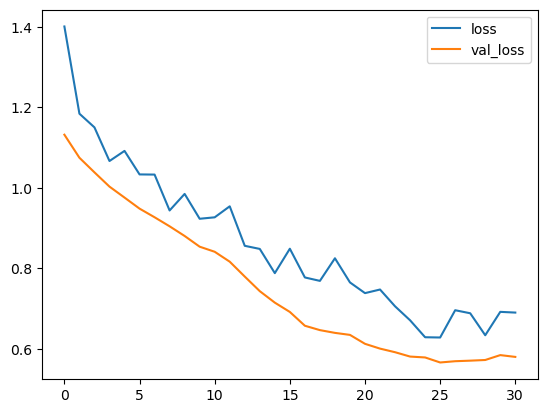

In [35]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()

In [36]:
y_pred_prob= model.predict(x_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [37]:
y_pred_indices= np.argmax(y_pred_prob, axis=1)
y_pred= onehot.categories_[0][y_pred_indices]

In [38]:
accuracy_score(y_test, y_pred)

0.8933333333333333